In [1]:
import json, subprocess, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
import os
from prettyprinter import pprint
os.chdir(Path.cwd().parent)
import re
import glob, statistics as stats
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

In [2]:

# ------------------------------------------------------------------
# CONFIG –––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
EXP_A = Path("/Users/alexandrucoca/work/dev/robust-dst-v2/metrics/sgd_turnslot")  # experiment 1   (use the parent that holds the seed_* dirs)
EXP_B = Path("/Users/alexandrucoca/work/dev/robust-dst-v2/metrics/sgd_turn")  # experiment 2
SERVICES = ["Travel_1", "RideSharing_2", "Movies_1", "Hotels_2", "Weather_1", "Services_1"]
METRIC   = "joint_goal_accuracy"
# ------------------------------------------------------------------
_suffix_re = re.compile(r"_([0-9]+)$")

def strip_variant(name: str) -> str:
    """Remove the *last* digit of a numeric suffix: `Weather_13` → `Weather_1`."""
    if name.startswith("#"):
        return name
    m = _suffix_re.search(name)
    if not m:
        return name
    digits = m.group(1)
    if len(digits) <= 1:
        return name
    return name[: m.start(1)] + digits[:-1]

def run_avg(exp_root):
    """Call average_metrics.py and get the full JSON dict."""
    cmd = [
        "python",
        "scripts/turn_issues_analysis.py",
        str(exp_root),
        "-",  # -> write to stdout
        "--metric", METRIC,
    ]
    result = subprocess.check_output(cmd, text=True)
    json_part = result[result.find("{") : result.rfind("}")+1]     # crude but works
    return json.loads(json_part)

def collect_service_means(avg_dict):
    """Across variants, compute the mean metric for each requested service."""
    pprint(avg_dict['v1'].keys())
    per_service = {s: [] for s in SERVICES}
    for variant_data in avg_dict.values():                 # v1…v5
        for key, metrics in variant_data.items():          # every service key
            stripped = strip_variant(key)      # Weather_13 -> Weather_1
            if stripped in per_service:
                per_service[stripped].append(metrics[METRIC])
    pprint(per_service)
    return {s: (sum(vals)/len(vals) if vals else float("nan"))
            for s, vals in per_service.items()}

def collect_service_stats(avg_dict):
    """
    Return mean and std of the metric for each requested service
    across the five variants *within the same experiment*.

    Returns
    -------
    dict  { service: (mean, std) }
    """
    per_service = {s: [] for s in SERVICES}

    for variant_data in avg_dict.values():          # v1 … v5
        for key, metrics in variant_data.items():   # every service key
            canonical = strip_variant(key)
            if canonical in per_service:
                per_service[canonical].append(metrics[METRIC])

    # convert to mean/std
    return {
        s: (stats.mean(vals), stats.stdev(vals) if len(vals) > 1 else 0.0)
        for s, vals in per_service.items()
    }


def per_seed_values(experiment_root: Path, variant: str, service: str, metric: str):
    """Return a list of values (one per seed) for a service in a given variant."""
    pattern = f"{experiment_root}/seed_*/{variant}/test/version_9/*_metrics.json"
    vals = []
    for path in glob.glob(pattern):
        with open(path) as f:
            data = json.load(f)
        for key, m in data.items():
            if strip_variant(key) == service:
                vals.append(m[metric])
                break
    return vals



rows = []
for tag, root in [("TurnSlot", EXP_A), ("Turn", EXP_B)]:
    stats_dict = collect_service_stats(run_avg(root))
    for svc, (mean_val, std_val) in stats_dict.items():
        rows.append({
            "service": svc,
            "experiment": tag,
            "mean": mean_val,
            "std":  std_val,
        })

df_bars = pd.DataFrame(rows).sort_values(["experiment", "service"])

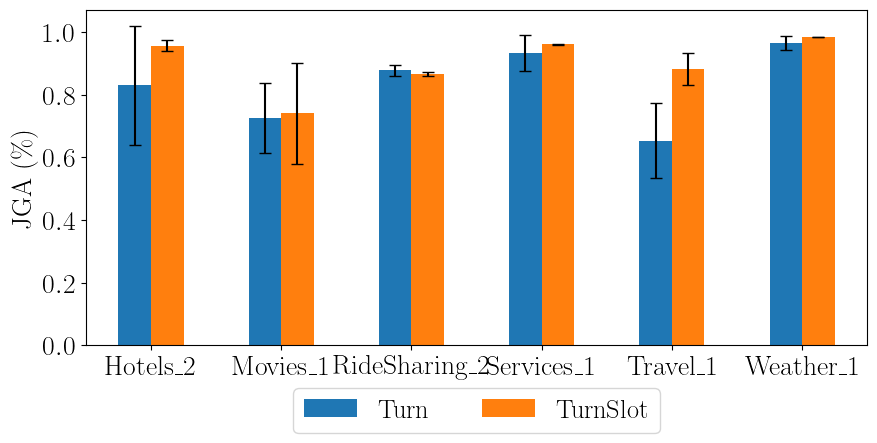

,service,experiment,mean,std
9,Hotels_2,Turn,0.829808,0.190449
3,Hotels_2,TurnSlot,0.956351,0.017540
8,Movies_1,Turn,0.726202,0.111536
2,Movies_1,TurnSlot,0.740652,0.160233
7,RideSharing_2,Turn,0.877785,0.016584
1,RideSharing_2,TurnSlot,0.867040,0.006217
11,Services_1,Turn,0.933968,0.057085
5,Services_1,TurnSlot,0.960713,0.002409
6,Travel_1,Turn,0.653977,0.120744
0,Travel_1,TurnSlot,0.880863,0.051057


In [3]:

# ---------------- VISUAL -----------------
mean_piv = df_bars.pivot(index="service", columns="experiment", values="mean")
std_piv  = df_bars.pivot(index="service", columns="experiment", values="std")


ax = mean_piv.plot.bar(
    yerr=std_piv,           # <-- error bars
    capsize=4,              # little horizontal caps
    figsize=(9, 4),
    rot=0,
    ylabel="JGA (%)",
    fontsize=20,
)


# 1️⃣  Bump the *ylabel* text size
ax.set_ylabel("JGA (\%)", fontsize=20)

# 2️⃣  Suppress the automatic x-axis label (“service”)
ax.set_xlabel("")            # or ax.set_xlabel(None)

# (optional) keep the tick labels large
ax.tick_params(axis="both", labelsize=20)

# legend exactly as you had it
plt.tight_layout()
plt.legend(ncol=2, fontsize=19, loc="lower center",
           bbox_to_anchor=(0.5, -0.30))
plt.show()

# print the tidy table for reference
display(df_bars.sort_values(["service","experiment"]))


In [4]:
# ───────── second visual: service trends across the 5 variants ─────────
VARIANT_SERVICES = ["Travel_1", "Hotels_2"]          # pick any two

variant_rows = []
for tag, root in [("TurnSlot", EXP_A), ("Turn", EXP_B)]:
    for vnum in range(1, 6):                # v1 … v5
        variant = f"v{vnum}"
        for svc in VARIANT_SERVICES:
            vals = per_seed_values(root, variant, svc, METRIC)
            if not vals:                     # service missing in that variant
                continue
            variant_rows.append({
                "experiment": tag,
                "variant": variant,
                "vnum": vnum,
                "service": svc,
                "mean":  stats.mean(vals),
                "std":   stats.stdev(vals) if len(vals) > 1 else 0.0,
                # "sem": stats.stdev(vals)/len(vals)**0.5  # if you prefer SEM
            })

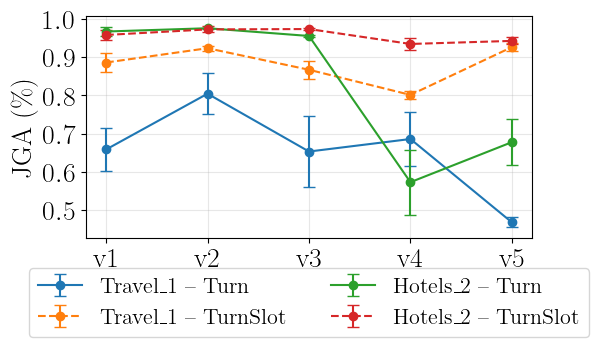

In [5]:
df_var = pd.DataFrame(variant_rows).sort_values(["vnum", "experiment"])

plt.figure(figsize=(6,4))
linestyles = {"Turn": "-", "TurnSlot": "--"}

for svc in VARIANT_SERVICES:
    for tag, style in linestyles.items():
        sub = df_var[(df_var["service"] == svc) & (df_var["experiment"] == tag)]
        plt.errorbar(
            sub["vnum"], sub["mean"],
            yerr=sub["std"],            # or sub["sem"]
            linestyle=style, marker="o", capsize=4,
            label=f"{svc} – {tag}"
        )

plt.xticks(range(1,6), [f"v{i}" for i in range(1,6)], fontsize=20)
plt.yticks(fontsize=20)
plt.ylabel("JGA (\%)", fontsize=20)
plt.grid(alpha=0.3)
plt.legend(
    fontsize=16, 
    ncol=2, 
    loc="lower center",
    bbox_to_anchor=(0.5, -0.5)
)
plt.tight_layout()
plt.show()

/var/folders/hj/m7y38vzs32n6ntpcjjkf3fzw0000gn/T/ipykernel_14354/2643698886.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


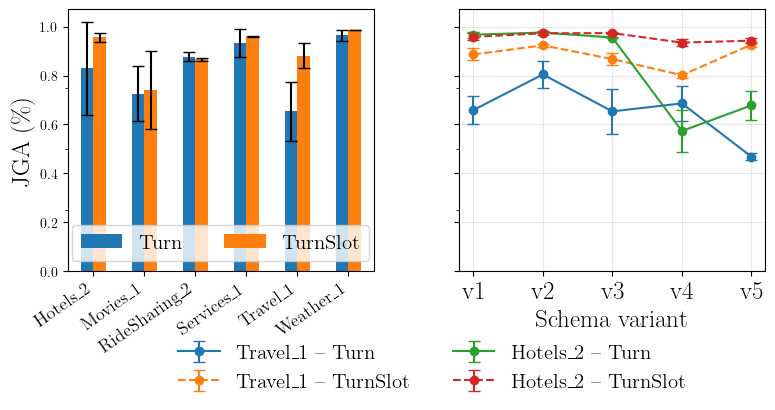

In [6]:
FIG_W, FIG_H = 9, 3.4          # overall size (tweak as you like)

fig, (ax_bar, ax_line) = plt.subplots(
    1, 2,
    figsize=(FIG_W, FIG_H),
    sharey=True,
    gridspec_kw={"wspace": 0.28}  # a touch more breathing room
)

# ── panel A : bars ─────────────────────────────────────────────
bars = mean_piv.plot.bar(
    yerr=std_piv,
    capsize=4,
    ax=ax_bar,
    rot=0,                    # keep ticks upright then rotate manually
    color=["tab:blue", "tab:orange"],
)

ax_bar.set_xlabel("")
ax_bar.set_ylabel("JGA (\\%)", fontsize=18)
ax_bar.tick_params()
# rotate & right-align tick labels so they don’t overlap
ax_bar.set_xticklabels(
    ax_bar.get_xticklabels(),
    rotation=35, 
    ha="right", 
    fontsize=13
)

# small legend for Turn vs TurnSlot *inside* the bar panel
ax_bar.legend(title="", fontsize=15, ncol=2, loc="lower center", frameon=True)

# ── panel B : lines + error bars ──────────────────────────────
linestyles = {"Turn": "-", "TurnSlot": "--"}

for svc in VARIANT_SERVICES:
    for tag, style in linestyles.items():
        sub = df_var[(df_var["service"] == svc) & (df_var["experiment"] == tag)]
        ax_line.errorbar(
            sub["vnum"], sub["mean"],
            yerr=sub["std"],
            marker="o", linestyle=style, capsize=4,
            label=f"{svc} – {tag}"
        )

ax_line.set_xticks(
    range(1, 6),
    [f"v{{{i}}}" for i in range(1, 6)],
    fontsize=14
)
ax_line.set_xlabel("Schema variant", fontsize=18)
ax_line.tick_params(axis="both", labelsize=18)
ax_line.grid(alpha=0.3)

# ── shared legend below the two panels (services × experiments) ──
handles, labels = ax_line.get_legend_handles_labels()
fig.legend(
    handles, labels,
    ncol=2, fontsize=15,
    loc="lower center",
    bbox_to_anchor=(0.53, -0.3),   # push a bit further down
    frameon=False
)

fig.tight_layout()
plt.show()
